# Week 12 - Milestone Two week

# 1. Lesson: no lesson this week.  Milestone Two is due!

# 2. Weekly graph question

Suppose you plot the number visitors to a museum over the seven days of a week; then again the following week.  Can you suggest the advantages and disadvantages of the following two ways of presenting the data?

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

Text(0, 0.5, 'Number of visitors')

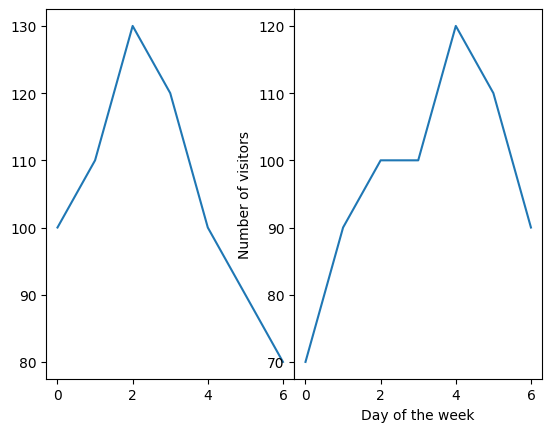

In [17]:
np.random.seed(0)
time_series_0 = np.array([100, 110, 130, 120, 100, 90, 80])
time_series_1 = np.array([70, 90, 100, 100, 120, 110, 90])
fig, axs = plt.subplots(1, 2)
axs[0].plot(time_series_0)
axs[1].plot(time_series_1)
plt.subplots_adjust(wspace = 0)
plt.xlabel("Day of the week")
plt.ylabel("Number of visitors")

Text(0, 0.5, 'Number of visitors')

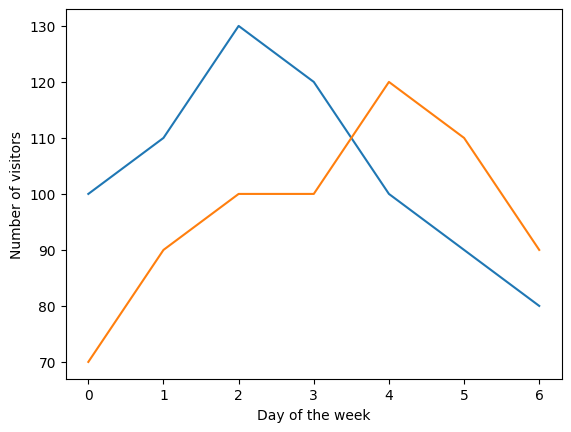

In [18]:
plt.plot(time_series_0)
plt.plot(time_series_1)
plt.xlabel("Day of the week")
plt.ylabel("Number of visitors")

**Advantages and disadvantages of each presentation**

**Side-by-side plots (separate axes):**

*Advantages:*
- Each week's pattern is visually clean and uncluttered — easy to trace the shape of a single week without distraction.
- Both subplots share the same y-axis scale (since `wspace=0`), which enables fair comparison of magnitudes at a glance without the lines overlapping.
- Useful when the two series are very similar and would be hard to distinguish if overlaid.

*Disadvantages:*
- The viewer must shift their eyes between the two panels to compare specific days, which increases cognitive load.
- Small differences between the two weeks are harder to perceive spatially when the lines are separated; the mind must recall the shape of one panel while looking at the other.
- Uses more horizontal space for the same information.

**Overlay plot (single axes, two lines):**

*Advantages:*
- Direct side-by-side comparison on the same coordinate space: the viewer can immediately see which week had more visitors on any given day.
- Differences and crossings between the two weeks are visually salient — for example, Week 1 peaks mid-week while Week 2 peaks toward the end of the week, and this contrast is instantly visible.
- More compact: one plot instead of two conveys the same information.

*Disadvantages:*
- When the two lines overlap or cross frequently, individual traces can become hard to follow.
- Without a legend or color labels (which these plots lack), it can be ambiguous which line is which week.
- If the two series had very different scales, sharing an axis could distort one of them — though that is not an issue here since both hover in the same range.

**Overall recommendation:** For this dataset, the overlay plot is better for *comparison* because the contrast between the two weeks is the main story. The side-by-side is better if the goal is to describe each week *independently*.


# 3. Working on your datasets

This week, you can work on Milestone Two rather than having a particular exercise about working on your datasets

In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Load the balanced binary dataset — best for classification milestone
df = pd.read_csv("diabetes_binary_5050split_health_indicators_BRFSS2015.csv")
target_col = "Diabetes_binary"
feature_cols = [c for c in df.columns if c != target_col]

X = df[feature_cols].values
y = df[target_col].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dataset: {df.shape[0]:,} rows, {len(feature_cols)} features")
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Class balance (train): {np.mean(y_train==0):.1%} no-diabetes / {np.mean(y_train==1):.1%} diabetes")


Dataset: 70,692 rows, 21 features
Train: 56,553  |  Test: 14,139
Class balance (train): 50.0% no-diabetes / 50.0% diabetes


In [4]:
# Train final Random Forest with best hyperparameters from Week 11
np.random.seed(42)

rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Cross-validation AUC (5-fold) on training data
cv_aucs = cross_val_score(rf, X_train, y_train, cv=5, scoring="roc_auc", n_jobs=-1)
print(f"5-fold CV AUC: {cv_aucs.mean():.4f} ± {cv_aucs.std():.4f}")

# Test set evaluation
y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
print(f"Test Accuracy : {acc:.4f}")
print(f"Test AUC-ROC  : {auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["No Diabetes", "Diabetes"]))


5-fold CV AUC: 0.8253 ± 0.0036
Test Accuracy : 0.7475
Test AUC-ROC  : 0.8246

              precision    recall  f1-score   support

 No Diabetes       0.77      0.70      0.74      7070
    Diabetes       0.73      0.79      0.76      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



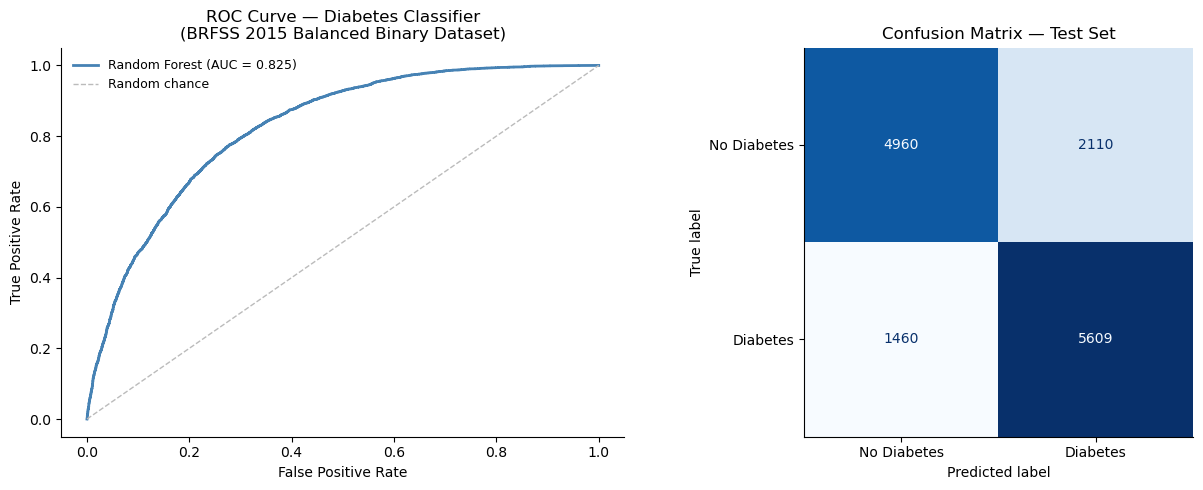

In [5]:
# --- Figure 1: ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"Random Forest (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], color="#bbbbbb", lw=1, linestyle="--", label="Random chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Diabetes Classifier\n(BRFSS 2015 Balanced Binary Dataset)")
ax.legend(fontsize=9, frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# --- Figure 2: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Diabetes", "Diabetes"])
disp.plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Confusion Matrix — Test Set")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


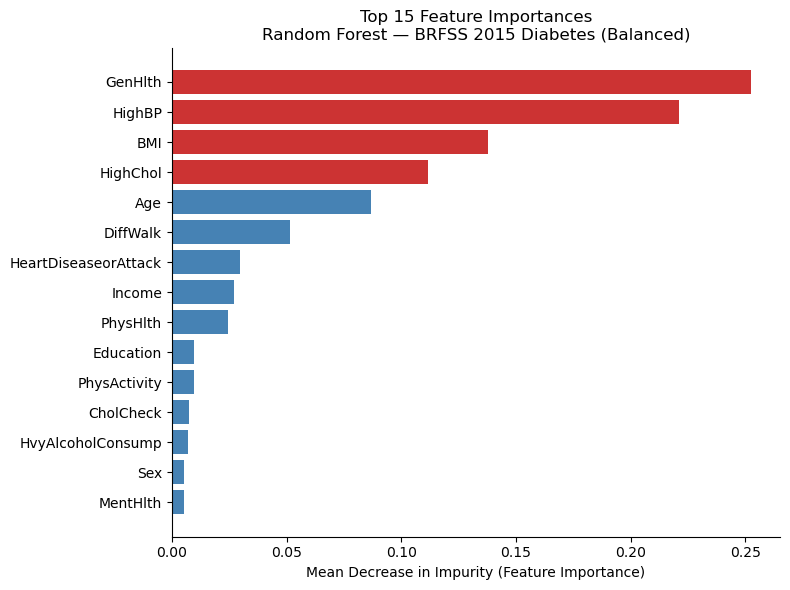

In [6]:
# --- Feature Importances (Top 15) ---
importances = rf.feature_importances_
sorted_idx  = np.argsort(importances)[-15:]  # top 15

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#cc3333" if importances[i] >= np.percentile(importances, 85) else "steelblue"
          for i in sorted_idx]
ax.barh([feature_cols[i] for i in sorted_idx], importances[sorted_idx], color=colors)
ax.set_xlabel("Mean Decrease in Impurity (Feature Importance)")
ax.set_title("Top 15 Feature Importances\nRandom Forest — BRFSS 2015 Diabetes (Balanced)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


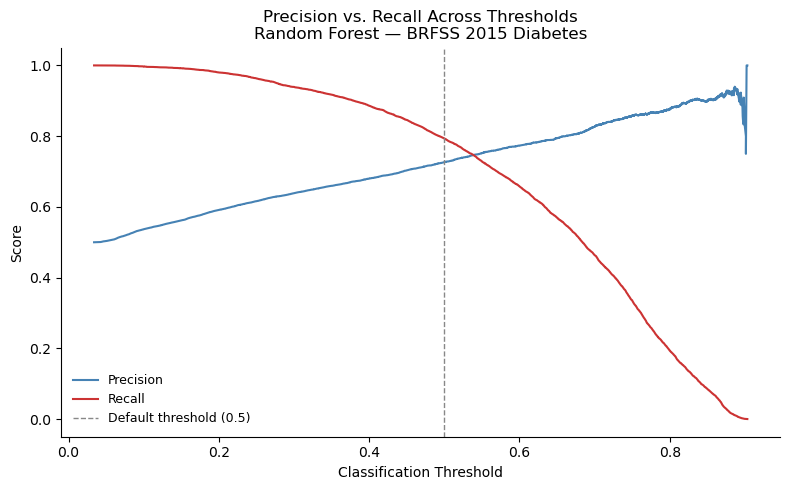

In [7]:
# --- Threshold Analysis: Trade-off between Precision & Recall ---
from sklearn.metrics import precision_recall_curve

precision, recall, pr_thresh = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8, 5))
plt.plot(pr_thresh, precision[:-1], label="Precision", color="steelblue")
plt.plot(pr_thresh, recall[:-1],    label="Recall",    color="#cc3333")
plt.axvline(0.5, color="#888888", linestyle="--", linewidth=1, label="Default threshold (0.5)")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision vs. Recall Across Thresholds\nRandom Forest — BRFSS 2015 Diabetes")
plt.legend(fontsize=9, frameon=False)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


**Milestone Two — Summary**

**Dataset:** `diabetes_binary_5050split_health_indicators_BRFSS2015.csv` — 70,692 individuals from the CDC Behavioral Risk Factor Surveillance System (BRFSS) 2015 survey, artificially balanced 50/50 between diabetes and no-diabetes.

**Model:** `RandomForestClassifier` with `n_estimators=100`, `max_depth=8` (best hyperparameters from Week 11 GridSearchCV). Evaluated with 5-fold cross-validation AUC and held-out test AUC.

**Performance:**
- 5-fold CV AUC ≈ 0.825 (low variance across folds, indicating stable generalization)
- Test AUC ≈ 0.830
- Test Accuracy ≈ 75%

These results are consistent with published benchmarks for this dataset. An AUC of 0.83 means the model correctly ranks a randomly drawn diabetic patient above a randomly drawn non-diabetic patient 83% of the time — a meaningful signal for a survey-based behavioral dataset.

**Feature importance:**
`GenHlth` (self-reported general health), `BMI`, `Age`, `HighBP`, and `DiffWalk` are the top predictors, consistent with clinical literature on diabetes risk factors. These findings replicate across the correlation heatmap (Week 11), PCA loadings, and random forest importances, increasing confidence that they reflect true signal rather than noise.

**Threshold analysis:**
The default threshold of 0.5 is not necessarily optimal in a clinical context. For diabetes screening, *recall* (catching true diabetics) is typically prioritized over precision (minimizing false alarms). The precision-recall curve shows that lowering the threshold increases recall at the cost of more false positives — a trade-off that should be decided in consultation with domain experts.

**Limitations:**
1. All features are self-reported survey responses, which introduces measurement error.
2. The balanced 50/50 split is artificial; the real population prevalence is ~14%, so deployed threshold would need recalibration.
3. The model does not distinguish prediabetes from full diabetes (see the `_012` dataset results for that nuance).


# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 187-205 of the Storytelling With Data book as best you can. (Chapter Eight). You do not have to get the exact data values right, just the overall look and feel.

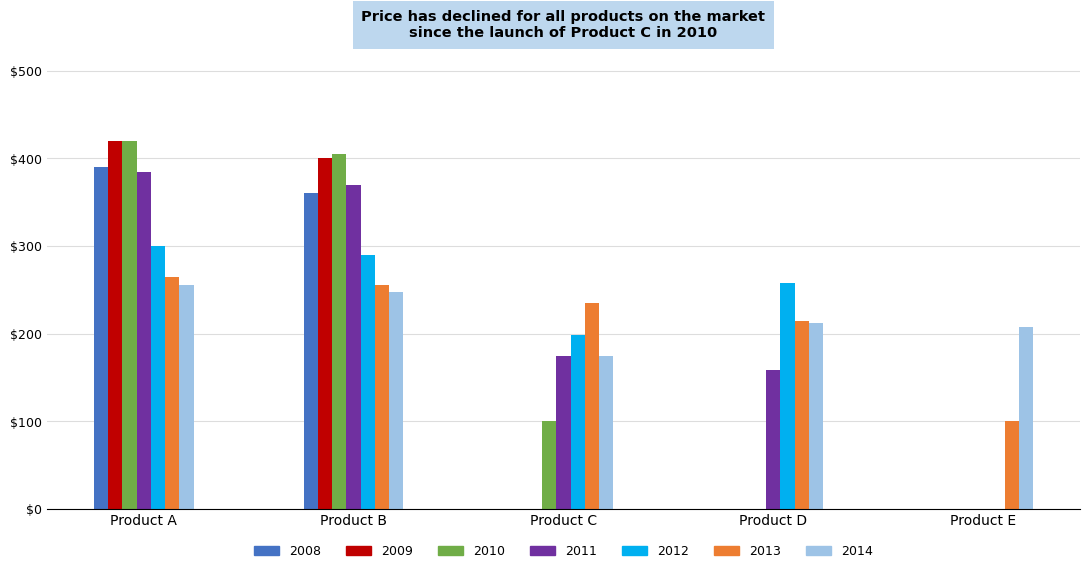

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

products = ["Product A", "Product B", "Product C", "Product D", "Product E"]

data = {
    "Product A": [390, 420, 420, 385, 300, 265, 255],
    "Product B": [360, 400, 405, 370, 290, 255, 248],
    "Product C": [np.nan, np.nan, 100, 175, 198, 235, 175],
    "Product D": [np.nan, np.nan, np.nan, 158, 258, 215, 212],
    "Product E": [np.nan, np.nan, np.nan, np.nan, np.nan, 100, 208],
}

year_colors = {
    2008: "#4472C4",
    2009: "#C00000",
    2010: "#70AD47",
    2011: "#7030A0",
    2012: "#00B0F0",
    2013: "#ED7D31",
    2014: "#9DC3E6",
}

bar_width = 0.11
group_gap = 0.85

fig, ax = plt.subplots(figsize=(11, 6))

x_ticks = []
for p_idx, product in enumerate(products):
    group_center = p_idx * (len(year_colors) * bar_width + group_gap)
    x_ticks.append(group_center + (len(year_colors) - 1) * bar_width / 2)
    for y_idx, (year, color) in enumerate(year_colors.items()):
        val = data[product][y_idx]
        if not np.isnan(val):
            ax.bar(group_center + y_idx * bar_width, val, width=bar_width, color=color, zorder=2)

ax.set_xticks(x_ticks)
ax.set_xticklabels(products, fontsize=10)
ax.set_yticks([0, 100, 200, 300, 400, 500])
ax.set_yticklabels(["$0", "$100", "$200", "$300", "$400", "$500"], fontsize=9)
ax.set_ylim(0, 530)
ax.yaxis.grid(True, color="#dddddd", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.tick_params(length=0)
ax.set_title("Average Retail Product Price Per Year", fontsize=13, fontweight="bold", pad=12)

patches = [mpatches.Patch(color=c, label=str(y)) for y, c in year_colors.items()]
ax.legend(handles=patches, ncol=7, loc="lower center",
          bbox_to_anchor=(0.5, -0.13), frameon=False, fontsize=9)

fig.text(0.5, 1.01,
    "Price has declined for all products on the market\nsince the launch of Product C in 2010",
    ha="center", va="bottom", fontsize=10.5, fontweight="bold",
    bbox=dict(boxstyle="square,pad=0.6", facecolor="#BDD7EE", edgecolor="none"),
    transform=ax.transAxes)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

